Gerando dataset: 100%|██████████| 30/30 [00:06<00:00,  4.97it/s]



=== Estatísticas ===
Rotação média: 3.55
Rotação min/max: -29.15 / 29.91
Escala média: 1.03
Escala min/max: 0.82 / 1.20
Gamma médio: 0.99
Gamma min/max: 0.70 / 1.28
Total de flips: 10/30


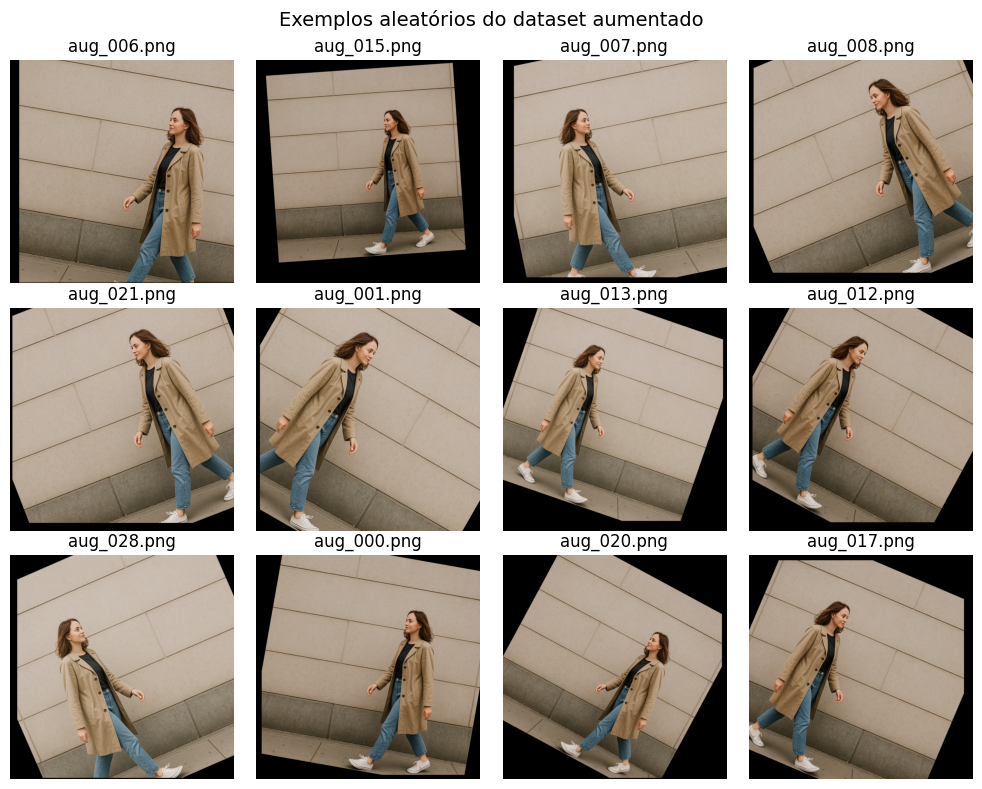

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

#Criando o diretorio de dataset
os.makedirs('dataset_aumentado', exist_ok=True)

#Configurando np.random
rng = np.random.default_rng()

#Configurando a imagem
img = cv2.imread('./drive/MyDrive/VC/w1.png') #Altere o caminho da imagem caso necessário
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#Dados utilizados para estatísticas
rotacoes = []
escalas = []
translacoes = []
gammas = []
flips = 0

#Loop Principal
for i in tqdm(range(30), desc="Gerando dataset"):

  #Trabalhando com a cópia para não afetar a orginal
  img_aug = img_rgb.copy()

  #Gerando valores aleatórios
  angulo = rng.uniform(-30, 30)
  escala = rng.uniform(0.8, 1.2)
  tx = rng.integers(-50, 51)
  ty = rng.integers(-50, 51)
  flip = rng.choice([True, False])
  gamma = rng.uniform(0.7,1.3)

  #Guardando os valores gerados para as estatísticas
  rotacoes.append(angulo)
  escalas.append(escala)
  translacoes.append((tx, ty))
  gammas.append(gamma)

  if flip:
      flips += 1

  #Rotação e Escalamento
  h,w = img.shape[:2]
  M_rot = cv2.getRotationMatrix2D((w/2, h/2), angulo, escala)
  img_aug = cv2.warpAffine(img_aug, M_rot, (w,h))

  #Translação
  M_trans = np.float32([[1, 0, tx], [0, 1, ty]])
  img_aug = cv2.warpAffine(img_aug, M_trans, (w, h))

  #Reflexão
  if flip:
    img_aug = cv2.flip(img_aug, 1)

  #Aplicar alteração de gamma
  img_aug = np.power(img_aug/255.0, gamma)
  img_aug = (img_aug * 255).astype(np.uint8)

  #Gravando as alterações
  nome_arquivo = f"dataset_aumentado/aug_{i:03d}.png"
  cv2.imwrite(nome_arquivo, cv2.cvtColor(img_aug, cv2.COLOR_RGB2BGR))

#Estatísticas
print("\n=== Estatísticas ===")
print(f"Rotação média: {np.mean(rotacoes):.2f}")
print(f"Rotação min/max: {min(rotacoes):.2f} / {max(rotacoes):.2f}")

print(f"Escala média: {np.mean(escalas):.2f}")
print(f"Escala min/max: {min(escalas):.2f} / {max(escalas):.2f}")

print(f"Gamma médio: {np.mean(gammas):.2f}")
print(f"Gamma min/max: {min(gammas):.2f} / {max(gammas):.2f}")

print(f"Total de flips: {flips}/30")

#Grade

#Lendo e selecionando as imagens do diretório
arquivos = os.listdir("dataset_aumentado")
selecionadas = rng.choice(arquivos, size=12, replace=False)

#Gerando a grade
plt.figure(figsize=(10, 8))

for i, nome in enumerate(selecionadas):
    caminho = os.path.join("dataset_aumentado", nome)

    img = cv2.imread(caminho)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 4, i+1)
    plt.imshow(img)
    plt.title(nome)
    plt.axis("off")

plt.suptitle("Exemplos aleatórios do dataset aumentado", fontsize=14)
plt.tight_layout()
plt.show()